### RAG Pipeline - Data Ingestion to Vector DB Pipeline

In [76]:
import os
from pathlib import Path

from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [77]:
### Read all the pdf's inside the directory

def process_all_pdfs(pdf_directory):
    "process all the pdf files in the directory" 
    all_documents=[]
    pdf_dir=Path(pdf_directory)
    #find all PDF files recursively
    pdf_files=list(pdf_dir.glob("**/*.pdf"))
    print(f"Found {len(pdf_files)} PDF files to process.")
    for pdf_file in pdf_files:
        print (f"Processing file: {pdf_file.name}")
        try:
            loader = PyMuPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
        except Exception as e:
            print(f"  ✗ Error: {e}")
        print(f"\n Total documents loaded: {len(all_documents)}")
    return all_documents
all_pdf_documents=process_all_pdfs("../data")


Found 2 PDF files to process.
Processing file: Harsha Verse Webdev Sheet.pdf
  ✓ Loaded 8 pages

 Total documents loaded: 8
Processing file: Ultimate AI Resource Sheet.pdf
  ✓ Loaded 25 pages

 Total documents loaded: 33


In [78]:
all_pdf_documents

[Document(metadata={'producer': '3-Heights™ PDF Merge Split Shell 6.12.1.11 (http://www.pdf-tools.com)', 'creator': '', 'creationdate': '', 'source': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'file_path': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'total_pages': 8, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-23T07:28:15+00:00', 'trapped': '', 'modDate': 'D:20241223072815Z', 'creationDate': '', 'page': 0, 'source_file': 'Harsha Verse Webdev Sheet.pdf', 'file_type': 'pdf'}, page_content="Harsha Verse\nHARSHA VERSE WEB DEV SHEET\nOVERVIEW:\nWeb Development is the process of building and maintaining websites and web applications. It\nincludes creating everything from simple landing pages to complex, interactive websites,\ninvolving both front-end (user-facing) and back-end (server-side) development.\nWhy it's still relevant and highly paid in 2025:\n1.\nUniversal Need for Online Presence: In today’s digital-first world, near

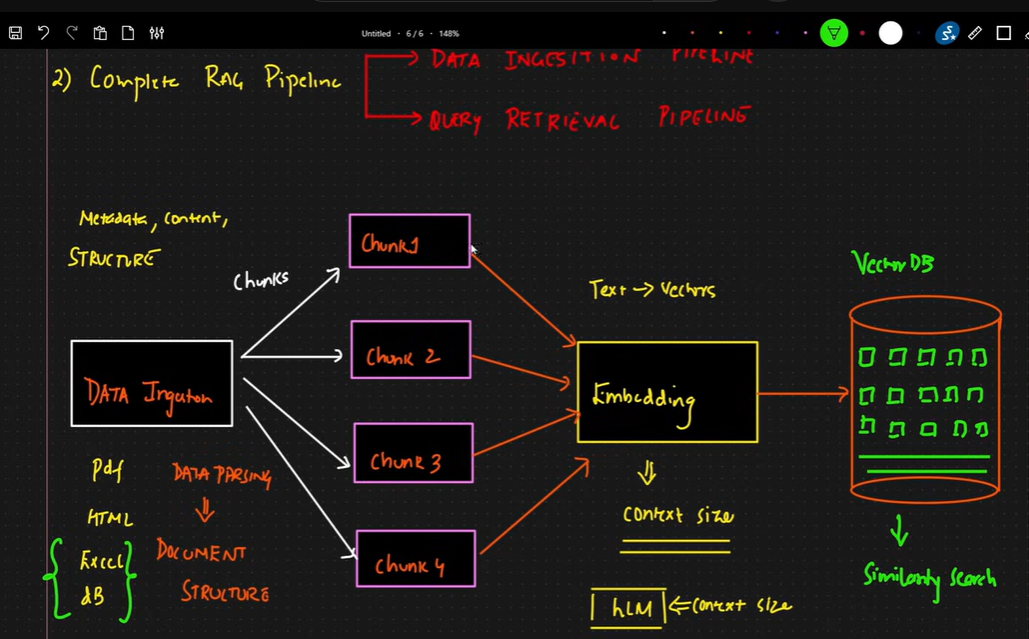

In [79]:
### Text Splitting get into chunks

def split_documents(documents, chunk_size=1000,chunk_overlap=200):
    "Split the documents into smaller chunks for the better RAG performance"
    text_splitter=RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
        )
    split_docs=text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    # show example chunk
    if split_docs:
        print("\nExample chunk:")
        print(f"Content:{split_docs[0].page_content[:200]}...")
        print(f"Metadata:{split_docs[0].metadata}")
    return split_docs
    

In [80]:
chunks=split_documents(all_pdf_documents)
chunks

Split 33 documents into 59 chunks

Example chunk:
Content:Harsha Verse
HARSHA VERSE WEB DEV SHEET
OVERVIEW:
Web Development is the process of building and maintaining websites and web applications. It
includes creating everything from simple landing pages to...
Metadata:{'producer': '3-Heights™ PDF Merge Split Shell 6.12.1.11 (http://www.pdf-tools.com)', 'creator': '', 'creationdate': '', 'source': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'file_path': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'total_pages': 8, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-23T07:28:15+00:00', 'trapped': '', 'modDate': 'D:20241223072815Z', 'creationDate': '', 'page': 0, 'source_file': 'Harsha Verse Webdev Sheet.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': '3-Heights™ PDF Merge Split Shell 6.12.1.11 (http://www.pdf-tools.com)', 'creator': '', 'creationdate': '', 'source': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'file_path': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'total_pages': 8, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-23T07:28:15+00:00', 'trapped': '', 'modDate': 'D:20241223072815Z', 'creationDate': '', 'page': 0, 'source_file': 'Harsha Verse Webdev Sheet.pdf', 'file_type': 'pdf'}, page_content="Harsha Verse\nHARSHA VERSE WEB DEV SHEET\nOVERVIEW:\nWeb Development is the process of building and maintaining websites and web applications. It\nincludes creating everything from simple landing pages to complex, interactive websites,\ninvolving both front-end (user-facing) and back-end (server-side) development.\nWhy it's still relevant and highly paid in 2025:\n1.\nUniversal Need for Online Presence: In today’s digital-first world, near

 ### Embedding and Vectorstore DB

In [81]:
## Sentence transformer for embedding

import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity




In [82]:
class EmbeddingManager:
    """Handles document embedding genration using SentenceTransformer
    """
    def __init__(self, model_name:str = "all-MiniLM-L6-v2"):
        
        """Initialize the embedding manager
        ARgs: 
            model_name: HuggingFace model name for sentence embeddings"""
        self.model_name=model_name
        self.model= None
        self._load_model()
    def _load_model(self):
        """Load the SentenceTransformer MOdel """
        try:
            print(f"Loading Embedding MOdel: {self.model_name}")
            self.model=SentenceTransformer(self.model_name)
            print(f"MOdel Loaded Successfully. Embedding Dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model{self.model_name}:{e}")
    def generate_embeddings(self,texts:List[str]) -> np.ndarray:
        """Generate embeddings for a list of texts
        
        Args:
        texts: List of text strings to embed
        
        Returns:
        numpy array of embeddings with shape (len(texts),embeddings_dim)
        
        Example:
        ✔ Input: 3 texts
        ✔ Output shape: (3, 384)
        """
        if not self.model:
            raise ValueError(" MOdel Not Loaded")
        print(f"Generating Embeddings for {len(texts)} texts")
        embeddings=self.model.encode(texts,show_progress_bar=True)
        print(f"Generating embedding with shape:",embeddings.shape)
        return embeddings



### Initaialize the embedding manger
embedding_manager=EmbeddingManager()
embedding_manager

Loading Embedding MOdel: all-MiniLM-L6-v2
MOdel Loaded Successfully. Embedding Dimension: 384


### Vector Store

In [83]:
import os
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore
    

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 118


In [84]:
chunks


[Document(metadata={'producer': '3-Heights™ PDF Merge Split Shell 6.12.1.11 (http://www.pdf-tools.com)', 'creator': '', 'creationdate': '', 'source': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'file_path': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'total_pages': 8, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-23T07:28:15+00:00', 'trapped': '', 'modDate': 'D:20241223072815Z', 'creationDate': '', 'page': 0, 'source_file': 'Harsha Verse Webdev Sheet.pdf', 'file_type': 'pdf'}, page_content="Harsha Verse\nHARSHA VERSE WEB DEV SHEET\nOVERVIEW:\nWeb Development is the process of building and maintaining websites and web applications. It\nincludes creating everything from simple landing pages to complex, interactive websites,\ninvolving both front-end (user-facing) and back-end (server-side) development.\nWhy it's still relevant and highly paid in 2025:\n1.\nUniversal Need for Online Presence: In today’s digital-first world, near

In [85]:
### Convert the text to embeddings
texts=[doc.page_content for doc in chunks]

## Generate the Embeddings

embeddings=embedding_manager.generate_embeddings(texts)

##store int he vector dtaabase
vectorstore.add_documents(chunks,embeddings)

Generating Embeddings for 59 texts


Batches: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]

Generating embedding with shape: (59, 384)
Adding 59 documents to vector store...
Successfully added 59 documents to vector store
Total documents in collection: 177


### Retriever Pipeline From VectorStore


In [86]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )
            
            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)

In [87]:
rag_retriever


In [88]:
rag_retriever.retrieve("What is AI?")


Retrieving documents for query: 'What is AI?'
Top K: 5, Score threshold: 0.0
Generating Embeddings for 1 texts


Batches: 100%|██████████| 1/1 [00:00<00:00, 68.35it/s]

Generating embedding with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_e51fe417_24',
  'content': "●\u200b Robotics – Intelligent movement and manipulation of physical objects.\u200b\n \n●\u200b Planning & Reasoning – Decision-making processes, logical inference.\u200b\n \n●\u200b Knowledge Representation – Storing knowledge in a way machines can reason \nabout.\u200b\n \nReal-World Example:\u200b\n ♟️ A chess-playing AI doesn't just recognize past game patterns (ML), it also: \n●\u200b Plans several moves ahead.\u200b\n \n●\u200b Evaluates the game state.\u200b\n \n●\u200b Remembers previous strategies.\u200b\n \n●\u200b Adapts to new opponents.\u200b\n \nHence, it uses AI = ML + Planning + Reasoning + Memory + Sensory Input \nAI Applications: \n●\u200b Chatbots (like ChatGPT)\u200b\n \n●\u200b Self-driving cars\u200b\n \n●\u200b Fraud detection\u200b\n \n●\u200b Language translation\u200b\n \n●\u200b Virtual assistants (like Siri, Alexa)\u200b\n \nCHAPTER 2: AI vs Generative AI — Machines That \nThink vs Create \n \n2.1 Traditional AI \nWha

In [89]:
rag_retriever.retrieve("what is RAG explain in detail .")


Retrieving documents for query: 'what is RAG explain in detail .'
Top K: 5, Score threshold: 0.0
Generating Embeddings for 1 texts


Batches: 100%|██████████| 1/1 [00:00<00:00, 50.81it/s]

Generating embedding with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_88e1586d_58',
  'content': '●\u200b Learning RAG from Scratch \n●\u200b Master RAG in 5 Hours\u200b',
  'metadata': {'producer': 'Skia/PDF m144 Google Docs Renderer',
   'title': 'Ultimate AI Resource Sheet',
   'creationDate': '',
   'creator': '',
   'format': 'PDF 1.4',
   'source_file': 'Ultimate AI Resource Sheet.pdf',
   'file_path': '..\\data\\pdf\\Ultimate AI Resource Sheet.pdf',
   'trapped': '',
   'content_length': 55,
   'subject': '',
   'page': 24,
   'doc_index': 58,
   'moddate': '',
   'modDate': '',
   'source': '..\\data\\pdf\\Ultimate AI Resource Sheet.pdf',
   'author': '',
   'total_pages': 25,
   'file_type': 'pdf',
   'keywords': '',
   'creationdate': ''},
  'similarity_score': 0.2452041506767273,
  'distance': 0.7547958493232727,
  'rank': 1},
 {'id': 'doc_1b74f3c3_58',
  'content': '●\u200b Learning RAG from Scratch \n●\u200b Master RAG in 5 Hours\u200b',
  'metadata': {'format': 'PDF 1.4',
   'total_pages': 25,
   'source': '..\\data\\pdf\\Ultim

### Integration Vectordb Context pipeline With LLM output


In [90]:
import google.generativeai as genai


In [94]:
import google.generativeai as genai

for m in genai.list_models():
    print(m.name, " | supports:", m.supported_generation_methods)


models/embedding-gecko-001  | supports: ['embedText', 'countTextTokens']
models/gemini-2.5-flash  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-exp  | supports: ['generateContent', 'countTokens', 'bidiGenerateContent']
models/gemini-2.0-flash  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-exp-image-generation  | supports: ['generateContent', 'countTokens', 'bidiGenerateContent']
models/gemini-2.0-flash-lite-001  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite  | supports: ['generateContent', 'countTokens', 'createCachedContent', 'batch

In [91]:
import os
from dotenv import load_dotenv

load_dotenv()

# Configure with your API key
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

# Initialize a Gemini model
gemini_model = genai.GenerativeModel("gemini-pro-latest")

In [95]:
from dotenv import load_dotenv
import os

load_dotenv()

print("Key loaded Successfully")


Key loaded Successfully


In [93]:
def rag_simple_gemini(query, retriever, model=gemini_model, top_k=3):

    # 1. Retrieve relevant documents
    results = retriever.retrieve(query, top_k=top_k)
    context = "\n\n".join([doc['content'] for doc in results]) if results else ""

    if not context:
        return "No relevant context found."

    # 2. Build prompt for Gemini
    prompt = f"""
    Use the following context to answer the question concisely.

    Context:
    {context}

    Question: {query}

    Answer:
    """

    # 3. Call Gemini LLM
    response = model.generate_content(prompt)

    return response.text


In [75]:
answer = rag_simple_gemini("What is machine learning?", rag_retriever)
print(answer)


Retrieving documents for query: 'What is machine learning?'
Top K: 3, Score threshold: 0.0
Generating Embeddings for 1 texts


Batches: 100%|██████████| 1/1 [00:00<00:00, 45.38it/s]

Generating embedding with shape: (1, 384)
Retrieved 3 documents (after filtering)


Machine Learning is a subset of AI where machines learn from data to make decisions or predictions without being explicitly programmed for each rule. Instead of writing rules manually, you provide data, and the model learns the mapping automatically.
